In [1]:
import pandas as pd

In [2]:
import numpy as np

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
 import xgboost as xgb
  HAS_XGB = True
except ImportError:
  HAS_XGB = False
print("XGBoost not found — using GradientBoosting instead")

In [ ]:
import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not found — skipping SHAP plots (pip install shap)")

In [8]:
data = pd.read_csv("/Users/anamikavns/Library/CloudStorage/OneDrive-Personal/Documents/anamika/Independent-Projects/hospital_readmission_dataset.csv")

In [9]:
data

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,P07996,2022-01-11,Winter,95,Female,East,COPD,6,9,Interventional,11,6,2,Medicare,Skilled Nursing,0.97,1
7996,P07997,2022-05-05,Spring,63,Female,East,Kidney Disease,4,7,Surgical,7,4,1,Medicaid,Home Health,0.94,1
7997,P07998,2021-08-26,Summer,43,Female,East,Diabetes,3,6,Medical,4,2,3,Uninsured,Home Health,0.79,1
7998,P07999,2021-04-20,Spring,86,Male,West,Sepsis,7,12,Interventional,12,5,3,Medicare,Skilled Nursing,0.97,1


In [10]:
data.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [11]:
data.tail()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
7995,P07996,2022-01-11,Winter,95,Female,East,COPD,6,9,Interventional,11,6,2,Medicare,Skilled Nursing,0.97,1
7996,P07997,2022-05-05,Spring,63,Female,East,Kidney Disease,4,7,Surgical,7,4,1,Medicaid,Home Health,0.94,1
7997,P07998,2021-08-26,Summer,43,Female,East,Diabetes,3,6,Medical,4,2,3,Uninsured,Home Health,0.79,1
7998,P07999,2021-04-20,Spring,86,Male,West,Sepsis,7,12,Interventional,12,5,3,Medicare,Skilled Nursing,0.97,1
7999,P08000,2021-06-12,Summer,93,Female,North,Kidney Disease,7,8,Conservative,10,6,3,Medicare,Skilled Nursing,0.97,1


In [12]:
data.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [18]:
data.columns

Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='object')

In [19]:
data.shape

(8000, 17)

In [9]:
data.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

In [ ]:
#Exploratory Data Analysis

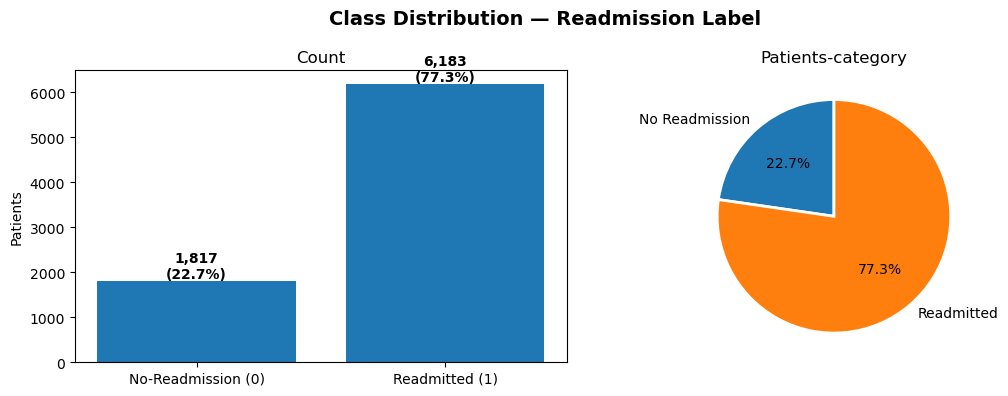

In [14]:
# Only needed in Jupyter
%matplotlib inline

import matplotlib.pyplot as plt

# Ensure label column exists
counts = data["label"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Class Distribution — Readmission Label", fontsize=14, fontweight="bold")

# ✅ Bar plot
labels = ["No-Readmission (0)", "Readmitted (1)"]
axes[0].bar(labels, counts.values)

# Add annotations
for i, v in enumerate(counts.values):
    axes[0].text(
        i,
        v + max(counts.values) * 0.01,  # dynamic spacing
        f"{v:,}\n({v/len(data)*100:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_title("Count")
axes[0].set_ylabel("Patients")

# ✅ Pie chart
axes[1].pie(
    counts.values,
    labels=["No Readmission", "Readmitted"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[1].set_title("Patients-category")

plt.tight_layout()
plt.show()

In [ ]:
### Age Distribution

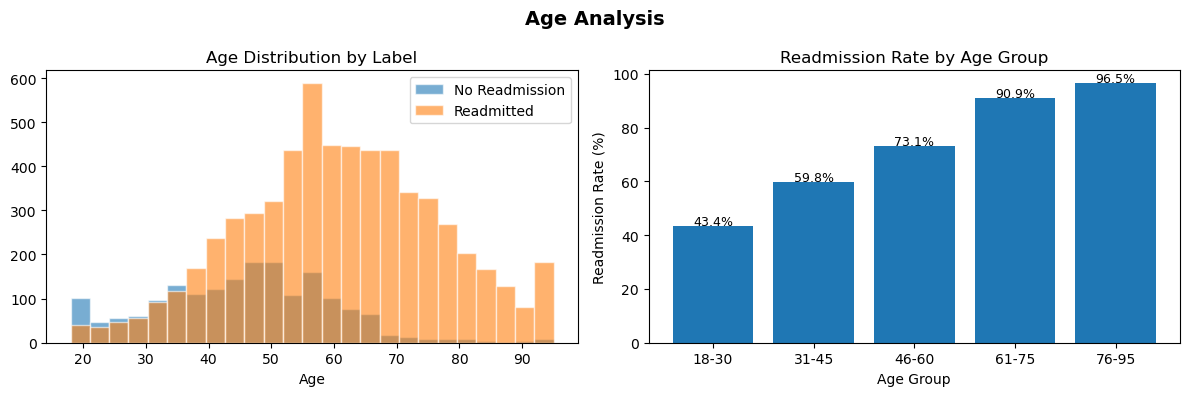

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Age Analysis", fontsize=14, fontweight="bold")

# Modify the loop to unpack 2 values (label, name)
for lbl, name in [(0, "No Readmission"), (1,"Readmitted")]:
    axes[0].hist(data[data["label"]==lbl]["age"], bins=25, alpha=0.6,
                 label=name, edgecolor="white")
axes[0].set_title("Age Distribution by Label")
axes[0].set_xlabel("Age"); axes[0].legend()

age_bins = pd.cut(data["age"], bins=[18,30,45,60,75,95],
                  labels=["18-30","31-45","46-60","61-75","76-95"])
rate = data.groupby(age_bins, observed=True)["label"].mean() * 100
axes[1].bar(rate.index, rate.values)
axes[1].set_title("Readmission Rate by Age Group")
axes[1].set_xlabel("Age Group"); axes[1].set_ylabel("Readmission Rate (%)")
for i, v in enumerate(rate.values):
    axes[1].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
## Chronological Features

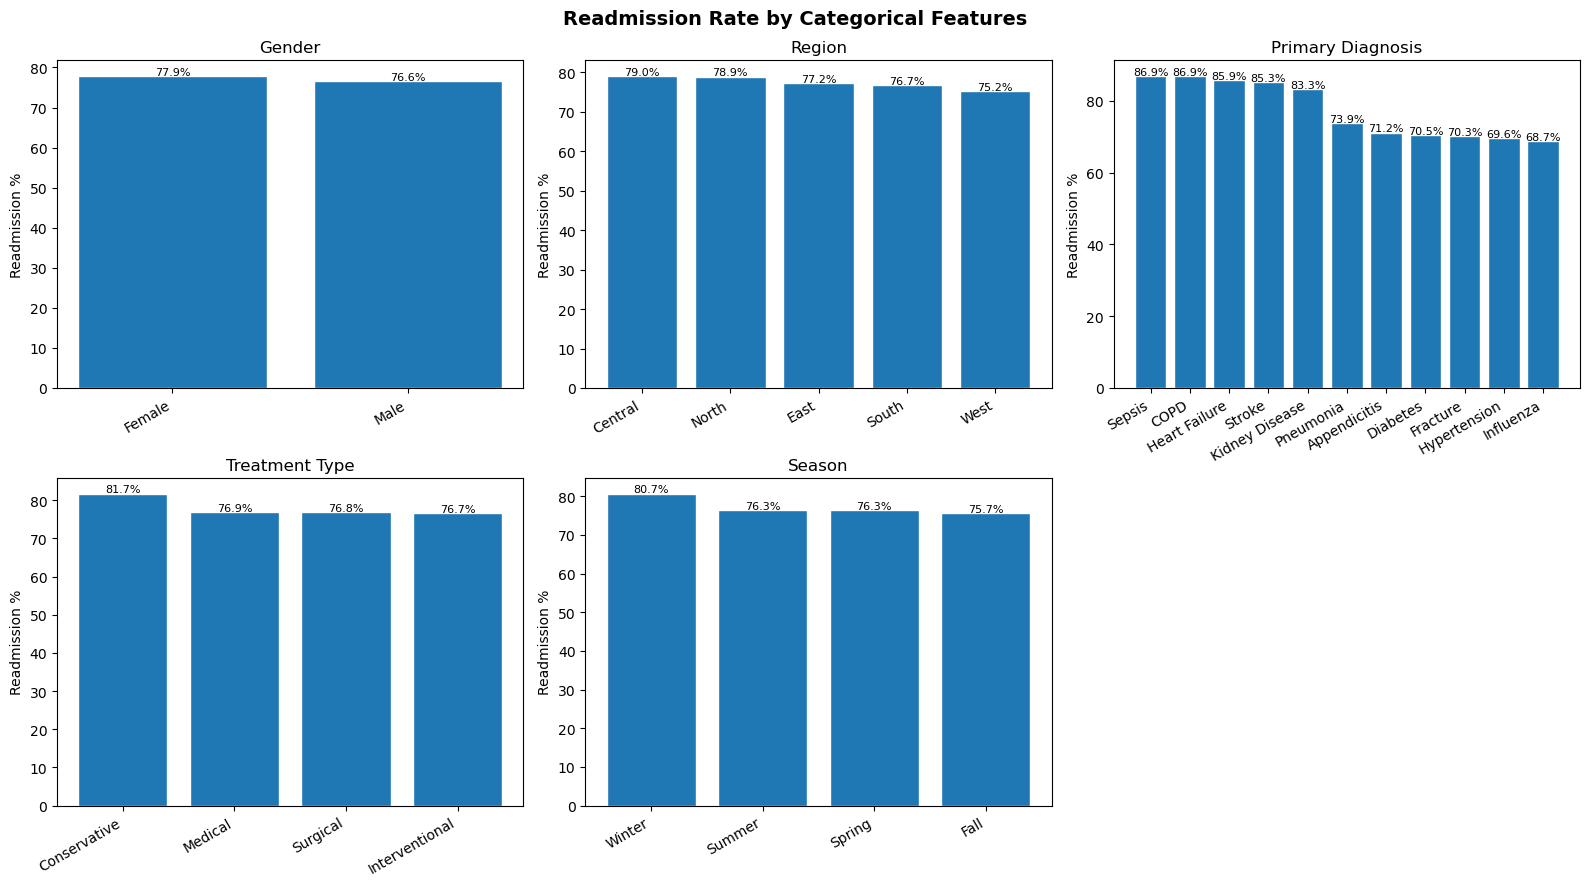

In [13]:
cat_cols = ["gender", "region", "primary_diagnosis", "treatment_type", "season"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Readmission Rate by Categorical Features", fontsize=14, fontweight="bold")
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    rate = data.groupby(col)["label"].mean().sort_values(ascending=False) * 100
    bars = axes[idx].bar(range(len(rate)), rate.values, edgecolor="white")
    axes[idx].set_xticks(range(len(rate)))
    axes[idx].set_xticklabels(rate.index, rotation=30, ha="right")
    axes[idx].set_title(col.replace("_", " ").title())
    axes[idx].set_ylabel("Readmission %")
    for bar, val in zip(bars, rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, val+0.3,
                       f"{val:.1f}%", ha="center", fontsize=8)

axes[5].set_visible(False)
plt.tight_layout()

In [ ]:
### Corelation Heatmap

Computing correlation matrix


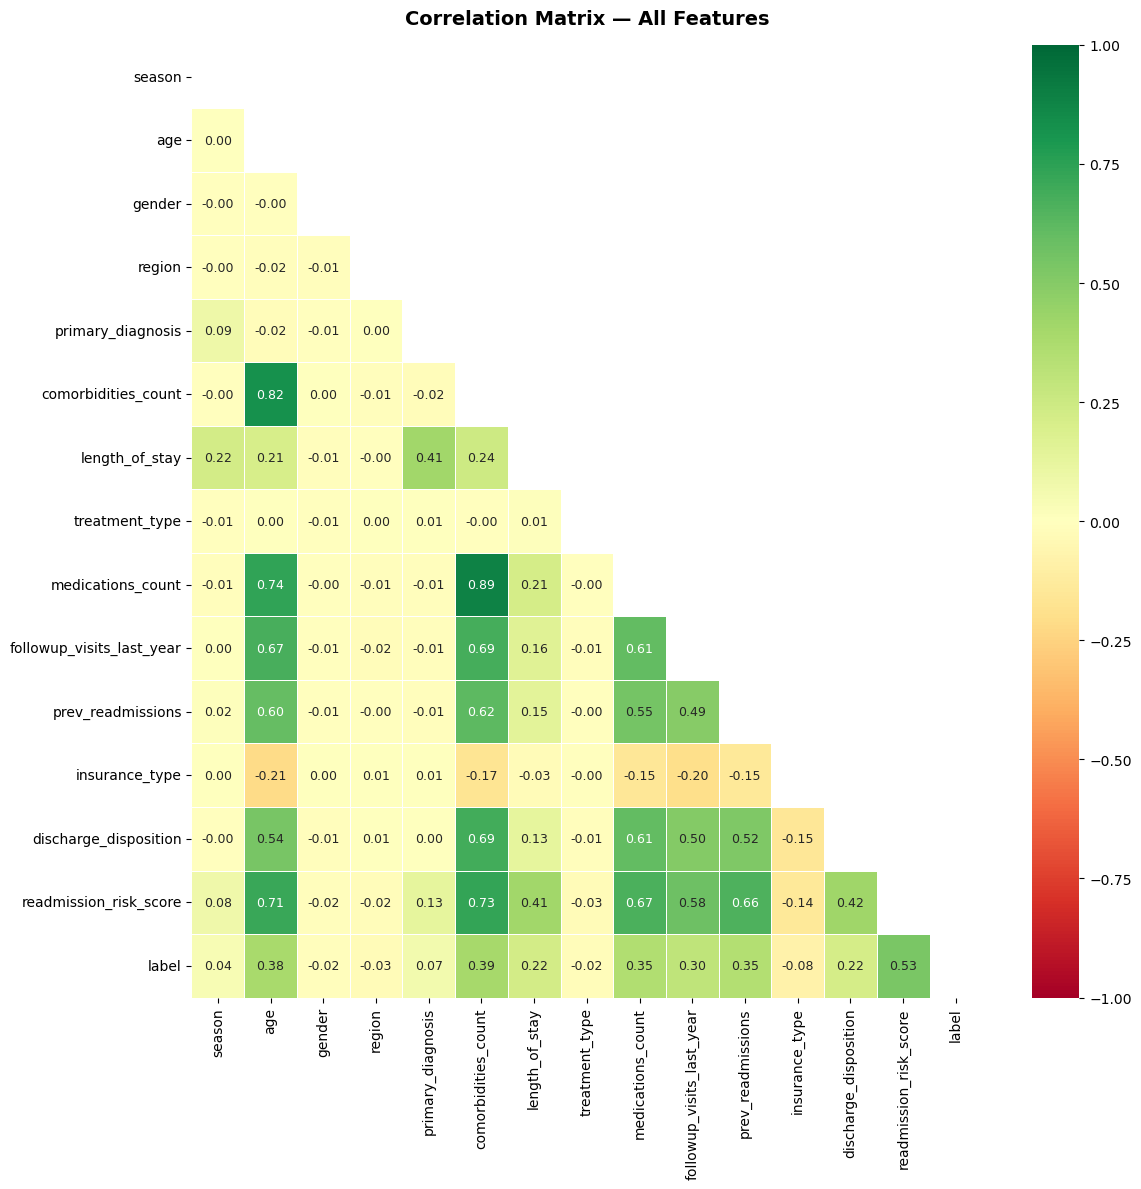

In [16]:
print("Computing correlation matrix")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Copy dataset
data_enc = data.copy()

# Label Encoding for categorical columns
le = LabelEncoder()

categorical_cols = [
    "gender",
    "region",
    "primary_diagnosis",
    "treatment_type",
    "season",
    "insurance_type",
    "discharge_disposition"
]

for col in categorical_cols:
    if col in data_enc.columns:
        data_enc[col] = le.fit_transform(data_enc[col].astype(str))

# Drop ID/date columns safely
data_enc = data_enc.drop(columns=["patient_id", "admission_date"], errors="ignore")

# Correlation matrix
corr = data_enc.corr(numeric_only=True)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 12))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9}
)

ax.set_title(
    "Correlation Matrix — All Features",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

In [ ]:
### Temporal Drift

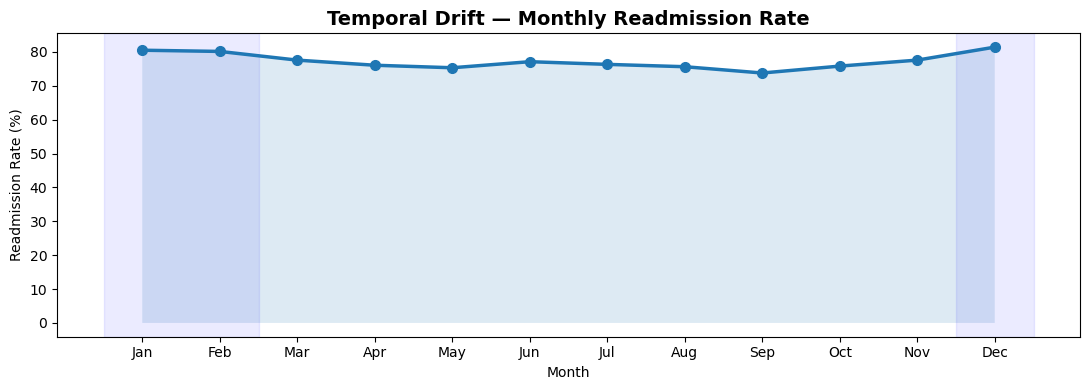

In [17]:
data["admission_date"] = pd.to_datetime(data["admission_date"])
data["month"] = data["admission_date"].dt.month
monthly = data.groupby("month")["label"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values, linewidth=2.5, marker="o", markersize=7)
ax.fill_between(monthly.index, monthly.values, alpha=0.15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Temporal Drift — Monthly Readmission Rate",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Readmission Rate (%)")
ax.set_xlabel("Month")
# Shade winter
ax.axvspan(0.5, 2.5,  alpha=0.08, color="blue", label="Winter")
ax.axvspan(11.5, 12.5, alpha=0.08, color="blue")
plt.tight_layout()
plt.show()

In [ ]:
## Feature Engineering

In [18]:
data_ml = data_enc.copy()

data_ml["age_x_comorbidities"]   = data_ml["age"] * data_ml["comorbidities_count"]
data_ml["los_x_medications"]     = data_ml["length_of_stay"] * data_ml["medications_count"]
data_ml["high_risk_age"]         = (data_ml["age"] >= 65).astype(int)
data_ml["complex_case"]          = ((data_ml["comorbidities_count"] >= 4) &
                                    (data_ml["medications_count"] >= 6)).astype(int)
data_ml["frequent_visitor"]      = (data_ml["followup_visits_last_year"] >= 4).astype(int)
data_ml["short_stay"]            = (data_ml["length_of_stay"] <= 2).astype(int)

data_ml["risk_score_manual"]     = (
    data_ml["age"] / 95 * 0.3 +
    data_ml["comorbidities_count"] / 10 * 0.4 +
    data_ml["prev_readmissions"] / 5 * 0.3
)
data_ml["poly_age_como"]         = data_ml["age"] ** 2 + data_ml["comorbidities_count"] ** 2
data_ml["short_stay_highrisk"]   = data_ml["short_stay"] * data_ml["comorbidities_count"]
data_ml["prev_x_como"]           = data_ml["prev_readmissions"] * data_ml["comorbidities_count"]
data_ml["age_x_prev"]            = data_ml["age"] * data_ml["prev_readmissions"]
data_ml["meds_x_visits"]         = data_ml["medications_count"] * data_ml["followup_visits_last_year"]

drop_cols = ["readmission_risk_score", "month"]
X = data_ml.drop(columns=["label"] + drop_cols, errors="ignore")
y = data_ml["label"]

print(f"  Features after engineering: {X.shape[1]}")
print(f"  Feature list: {list(X.columns)}")

  Features after engineering: 25
  Feature list: ['season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'age_x_comorbidities', 'los_x_medications', 'high_risk_age', 'complex_case', 'frequent_visitor', 'short_stay', 'risk_score_manual', 'poly_age_como', 'short_stay_highrisk', 'prev_x_como', 'age_x_prev', 'meds_x_visits']


In [19]:
data_ml

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,...,high_risk_age,complex_case,frequent_visitor,short_stay,risk_score_manual,poly_age_como,short_stay_highrisk,prev_x_como,age_x_prev,meds_x_visits
0,1,66,1,3,2,5,6,1,8,6,...,1,1,1,0,0.468421,4381,0,5,66,48
1,0,55,1,3,2,4,6,1,6,4,...,0,1,1,0,0.513684,3041,0,12,165,24
2,1,69,0,4,5,6,8,2,9,6,...,1,1,1,0,0.577895,4797,0,12,138,54
3,2,83,1,3,10,6,11,2,11,4,...,1,1,1,0,0.622105,6925,0,12,166,44
4,0,54,0,2,10,4,10,2,6,2,...,0,1,0,0,0.390526,2932,0,4,54,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,3,95,0,1,1,6,9,1,11,6,...,1,1,1,0,0.660000,9061,0,12,190,66
7996,1,63,0,1,7,4,7,3,7,4,...,0,1,1,0,0.418947,3985,0,4,63,28
7997,2,43,0,1,2,3,6,2,4,2,...,0,0,0,0,0.435789,1858,0,9,129,8
7998,1,86,1,4,9,7,12,1,12,5,...,1,1,1,0,0.731579,7445,0,21,258,60


In [20]:
#### Model Training

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# Split data (with stratification for class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Compute sample weights for imbalanced classes
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Initialize model dictionary
models = {}

In [25]:
print(y_train.value_counts(normalize=True))

label
1    0.772813
0    0.227187
Name: proportion, dtype: float64


In [22]:
!pip install xgboost

In [21]:
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier

In [1]:
pip install --upgrade xgboost


Note: you may need to restart the kernel to use updated packages.


In [22]:
# ==============================
# XGBoost Training Pipeline
# ==============================

import numpy as np
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier

models = {}

# Check if XGBoost is available
try:
    HAS_XGB = True
except:
    HAS_XGB = False


# ==============================
# XGBoost Model
# ==============================
if HAS_XGB:
    print("🚀 Training XGBoost Model")

    xgb_model = xgb.XGBClassifier(
        n_estimators=800,
        max_depth=7,
        learning_rate=0.02,
        subsample=0.75,
        colsample_bytree=0.75,
        min_child_weight=5,
        gamma=0.2,
        reg_alpha=0.1,
        reg_lambda=1.5,
        scale_pos_weight=1.5,
        max_delta_step=1,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )

    # Fit model with evaluation set for early stopping
    xgb_model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=True
    )

    models["XGBoost"] = xgb_model

    # Optional: check best iteration
    print("Best iteration:", xgb_model.best_iteration)


# ==============================
# Fallback: Gradient Boosting
# ==============================
else:
    print("⚠️ XGBoost not available. Training GradientBoosting instead.")

    gb_model = GradientBoostingClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )

    gb_model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights
    )

    models["GradientBoosting"] = gb_model

🚀 Training XGBoost Model
[0]	validation_0-auc:0.81275	validation_1-auc:0.76195
[1]	validation_0-auc:0.82868	validation_1-auc:0.78273
[2]	validation_0-auc:0.83433	validation_1-auc:0.79540
[3]	validation_0-auc:0.83724	validation_1-auc:0.79613
[4]	validation_0-auc:0.83981	validation_1-auc:0.80148
[5]	validation_0-auc:0.84361	validation_1-auc:0.80622
[6]	validation_0-auc:0.84585	validation_1-auc:0.80917
[7]	validation_0-auc:0.84670	validation_1-auc:0.80941
[8]	validation_0-auc:0.84809	validation_1-auc:0.81029
[9]	validation_0-auc:0.84762	validation_1-auc:0.81107
[10]	validation_0-auc:0.84767	validation_1-auc:0.81138
[11]	validation_0-auc:0.84777	validation_1-auc:0.81135
[12]	validation_0-auc:0.84902	validation_1-auc:0.81217
[13]	validation_0-auc:0.85106	validation_1-auc:0.81353
[14]	validation_0-auc:0.85148	validation_1-auc:0.81406
[15]	validation_0-auc:0.85342	validation_1-auc:0.81407
[16]	validation_0-auc:0.85410	validation_1-auc:0.81350
[17]	validation_0-auc:0.85436	validation_1-auc:0.8

AttributeError: `best_iteration` is only defined when early stopping is used.

In [23]:
## Trainig Linear regression and Random Forest Model

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {}

# ✅ Logistic Regression with scaling pipeline
print("Training Logistic Regression")

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

lr_pipeline.fit(X_train, y_train)

models["LogisticRegression"] = lr_pipeline


# ✅ Random Forest (no scaling needed)
print("Training Random Forest")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

models["RandomForest"] = rf

Training Logistic Regression
Training Random Forest


In [24]:
print(models.keys())

dict_keys(['LogisticRegression', 'RandomForest'])


In [45]:
print(models.keys())

dict_keys(['LogisticRegression', 'RandomForest', 'XGBoost'])


In [25]:
### Model Evaluation

from sklearn.metrics import accuracy_score, roc_auc_score

results = []

for name, model in models.items():
    print("\n==============================")
    print("MODEL:", name)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    auc = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        if proba.shape[1] > 1:
            auc = roc_auc_score(y_test, proba[:, 1])

    print("Accuracy:", acc)
    print("ROC-AUC:", auc)

    results.append([name, acc, auc])


MODEL: LogisticRegression
Accuracy: 0.729375
ROC-AUC: 0.8116566562219534

MODEL: RandomForest
Accuracy: 0.758125
ROC-AUC: 0.8104496126102652


In [ ]:
# Best model
best_name = max(results, key=lambda k: results[k]["AUC"])
best_res   = results[best_name]
best_model = models[best_name]
if isinstance(best_model, tuple): best_model = best_model[1]
print(f"Best Model: {best_name} (AUC = {best_res['AUC']:.4f})")

In [30]:
results_dict = {}

for row in results:
    name, acc, auc = row
    results_dict[name] = {
        "Accuracy": acc,
        "AUC": auc
    }

In [28]:
model_names = list(results_dict.keys())

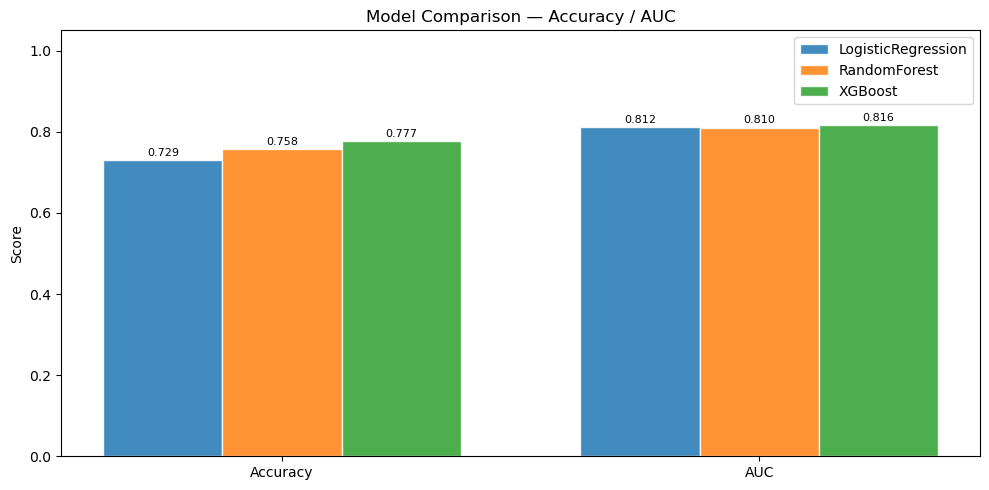

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

metrics = ["Accuracy", "AUC"]

model_names = [r[0] for r in results]

x = np.arange(len(metrics))
width = 0.25

for i, row in enumerate(results):
    name = row[0]
    vals = row[1:3]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=name,
        edgecolor="white",
        alpha=0.85
    )

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            v + 0.01,
            f"{v:.3f}",
            ha="center",
            fontsize=8
        )

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — Accuracy / AUC")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"\n  Classification Report — {best_name}:")
print(classification_report(y_test, best_res["y_pred"], target_names=["No Readmit", "Readmit"]))